In [1]:
# Import NumPy for array handling in the notebook.
import numpy as np

In [2]:
# Load input and fluid data for OP1 to OP6.
from load_op_inputs import load_op_input_and_fluid

# Load the requested OP inputs and fluid values in one bundle.
op_data = load_op_input_and_fluid([1, 2, 3, 4, 5, 6])

In [3]:
# Split the loaded bundle into separate variables for each OP.
inputSignals1 = op_data[1]["input_signals"]
fv1 = op_data[1]["fluidstoffwerte"]

inputSignals2 = op_data[2]["input_signals"]
fv2 = op_data[2]["fluidstoffwerte"]

inputSignals3 = op_data[3]["input_signals"]
fv3 = op_data[3]["fluidstoffwerte"]

inputSignals4 = op_data[4]["input_signals"]
fv4 = op_data[4]["fluidstoffwerte"]

inputSignals5 = op_data[5]["input_signals"]
fv5 = op_data[5]["fluidstoffwerte"]

inputSignals6 = op_data[6]["input_signals"]
fv6 = op_data[6]["fluidstoffwerte"]

In [4]:
# Load the FMU output time arrays T1 to T6 from the Batemo FMU1 files.
from pathlib import Path
import csv

dataset_root = Path(r"c:\Users\M0245635\Downloads")

def get_op_file(op_id: int, file_name: str) -> Path:
    file_path = dataset_root / f"OP{op_id}" / f"OP{op_id}" / file_name
    if not file_path.exists():
        file_path = dataset_root / f"OP{op_id}" / file_name
    return file_path

def load_csv_headers_and_data(file_path: Path) -> tuple[list[str], np.ndarray]:
    with file_path.open("r", encoding="utf-8-sig", newline="") as f:
        reader = csv.reader(f)
        headers = next(reader)

    data = np.genfromtxt(file_path, delimiter=",", skip_header=1, dtype=float)
    if data.ndim == 1:
        data = data.reshape(1, -1)
    return headers, data

fmu_data = {}
for op_id in range(1, 7):
    fmu_file = get_op_file(op_id, f"OP{op_id}_Batemo FMU1.csv")
    headers, data = load_csv_headers_and_data(fmu_file)
    fmu_data[op_id] = {"headers": headers, "data": data}

T1 = fmu_data[1]["data"][:, 0]
T2 = fmu_data[2]["data"][:, 0]
T3 = fmu_data[3]["data"][:, 0]
T4 = fmu_data[4]["data"][:, 0]
T5 = fmu_data[5]["data"][:, 0]
T6 = fmu_data[6]["data"][:, 0]

In [5]:
# Build FMU output matrices for OP1 to OP6 with column 1 = bc_Q and column 2 = bc_Soc, keeping NaN values.
def build_bc_matrix(op_id: int) -> np.ndarray:
    fmu_headers = fmu_data[op_id]["headers"]
    fmu_values = fmu_data[op_id]["data"]

    bc_q_idx = next(
        i for i, header in enumerate(fmu_headers)
        if "bc_Q Monitor" in header
    )
    bc_soc_idx = next(
        i for i, header in enumerate(fmu_headers)
        if "bc_SOC Monitor" in header
    )

    bc_q = fmu_values[:, bc_q_idx]
    bc_soc = fmu_values[:, bc_soc_idx]
    return np.column_stack((bc_q, bc_soc))

bc1 = build_bc_matrix(1)
bc2 = build_bc_matrix(2)
bc3 = build_bc_matrix(3)
bc4 = build_bc_matrix(4)
bc5 = build_bc_matrix(5)
bc6 = build_bc_matrix(6)

bc_time_match1 = len(T1) == bc1.shape[0]
bc_time_match2 = len(T2) == bc2.shape[0]
bc_time_match3 = len(T3) == bc3.shape[0]
bc_time_match4 = len(T4) == bc4.shape[0]
bc_time_match5 = len(T5) == bc5.shape[0]
bc_time_match6 = len(T6) == bc6.shape[0]

bc_time_matches = np.array(
    [bc_time_match1, bc_time_match2, bc_time_match3, bc_time_match4, bc_time_match5, bc_time_match6],
    dtype=bool,
 )
bc_time_matches

array([ True,  True,  True,  True,  True,  True])

In [6]:
# Example: get OP1 time, Q, and SOC at the nearest point to 10 s.
target_time = 10.0
idx_10 = np.argmin(np.abs(T1 - target_time))

t_10 = T1[idx_10]
q_10 = bc1[idx_10, 0]
soc_10 = bc1[idx_10, 1]

print(f"OP1 nearest time to {target_time} s: {t_10}")
print(f"OP1 Q at {t_10} s: {q_10}")
print(f"OP1 SOC at {t_10} s: {soc_10}")

OP1 nearest time to 10.0 s: 9.99999999999998
OP1 Q at 9.99999999999998 s: 61448.49178275082
OP1 SOC at 9.99999999999998 s: 10.525013180666273


In [7]:
# Header: fast OP sampler with efficient random multi-sample support.
from typing import Dict


# Build OP-indexed dictionaries from existing notebook variables.
# Each OP key (1..6) maps to a time vector, BC matrix, and static feature vectors.
t_by_op = {1: T1, 2: T2, 3: T3, 4: T4, 5: T5, 6: T6}
bc_by_op = {1: bc1, 2: bc2, 3: bc3, 4: bc4, 5: bc5, 6: bc6}
input_signals_by_op = {1: inputSignals1, 2: inputSignals2, 3: inputSignals3, 4: inputSignals4, 5: inputSignals5, 6: inputSignals6}
fluid_values_by_op = {1: fv1, 2: fv2, 3: fv3, 4: fv4, 5: fv5, 6: fv6}

# Use the original CSV column labels where available.
# These names are used in the returned header row of each sampled result.
input_headers_by_op = {op_id: [h.strip() for h in op_data[op_id]["input_headers"]] for op_id in range(1, 7)}
fluid_headers_by_op = {op_id: [h.strip() for h in op_data[op_id]["fluid_headers"]] for op_id in range(1, 7)}


def build_fast_sampler(
    t_by_op: Dict[int, np.ndarray],
    bc_by_op: Dict[int, np.ndarray],
    input_signals_by_op: Dict[int, np.ndarray],
    fluid_values_by_op: Dict[int, np.ndarray],
    input_headers_by_op: Dict[int, list[str]],
    fluid_headers_by_op: Dict[int, list[str]],
):
    """
    Prepare and return an efficient sampling callable.

    Returned callable
    -----------------
    sample(n_samples=1) -> np.ndarray
        If n_samples == 1:
            Returns a 2-row object array [headers, values].
        If n_samples > 1:
            Returns an object array with shape (n_samples + 1, n_cols):
            row 0 = headers, rows 1..n_samples = sampled values.

    Output order per sample:
    [op_id, time, inputs..., fluid values..., q, soc]
    """
    ops = sorted(t_by_op.keys())
    ops_arr = np.asarray(ops, dtype=int)
    rng = np.random.default_rng()

    cache = {}
    expected_n_cols = None
    canonical_headers = None

    for op_id in ops:
        t_vec = np.asarray(t_by_op[op_id], dtype=float).reshape(-1)
        if t_vec.size == 0:
            raise ValueError(f"T list for OP{op_id} is empty")

        bc_mat = np.asarray(bc_by_op[op_id], dtype=float)
        if bc_mat.ndim != 2 or bc_mat.shape[1] < 2:
            raise ValueError(f"bc_by_op[{op_id}] must have columns [Q, SOC]")
        if bc_mat.shape[0] != t_vec.size:
            raise ValueError(f"Length mismatch for OP{op_id}: len(t)={t_vec.size}, bc rows={bc_mat.shape[0]}")

        input_vals = np.asarray(input_signals_by_op[op_id], dtype=float).reshape(-1)
        fv_vals = np.asarray(fluid_values_by_op[op_id], dtype=float).reshape(-1)
        static_vals = np.concatenate([input_vals, fv_vals])

        in_headers = input_headers_by_op.get(op_id, [])
        fv_headers = fluid_headers_by_op.get(op_id, [])

        if len(in_headers) != input_vals.size:
            in_headers = [f"input_{i + 1}" for i in range(input_vals.size)]
        if len(fv_headers) != fv_vals.size:
            fv_headers = [f"fv_{i + 1}" for i in range(fv_vals.size)]

        headers = ["op_id", "time"] + in_headers + fv_headers + ["q", "soc"]

        if expected_n_cols is None:
            expected_n_cols = len(headers)
            canonical_headers = headers
        elif len(headers) != expected_n_cols:
            raise ValueError(
                f"Feature count mismatch. OP{op_id} has {len(headers)} columns, expected {expected_n_cols}."
            )

        cache[op_id] = {
            "t_vec": t_vec,
            "t_min": float(np.min(t_vec)),
            "t_max": float(np.max(t_vec)),
            "bc_mat": bc_mat,
            "static_vals": static_vals,
        }

    static_start = 2
    static_end = expected_n_cols - 2

    def sample(n_samples: int = 1) -> np.ndarray:
        """
        Draw n_samples random rows.

        Parameters
        ----------
        n_samples : int
            Number of random samples to draw. If n_samples=2, returns two random samples.
        """
        n_samples = int(n_samples)
        if n_samples < 1:
            raise ValueError("n_samples must be >= 1")

        op_ids = rng.choice(ops_arr, size=n_samples, replace=True)

        rows = np.empty((n_samples, expected_n_cols), dtype=object)
        rows[:, 0] = op_ids

        for op_id in ops:
            mask = op_ids == op_id
            if not np.any(mask):
                continue

            c = cache[op_id]
            m = int(np.sum(mask))
            sampled_times = rng.uniform(c["t_min"], c["t_max"], size=m)
            t_vec = c["t_vec"]

            if t_vec.size == 1:
                idx = np.zeros(m, dtype=int)
            else:
                pos = np.searchsorted(t_vec, sampled_times, side="left")
                pos = np.clip(pos, 1, t_vec.size - 1)
                left = pos - 1
                right = pos
                choose_right = np.abs(t_vec[right] - sampled_times) < np.abs(t_vec[left] - sampled_times)
                idx = np.where(choose_right, right, left)

            row_idx = np.flatnonzero(mask)
            rows[row_idx, 1] = t_vec[idx]
            rows[row_idx, static_start:static_end] = c["static_vals"]
            rows[row_idx, -2] = c["bc_mat"][idx, 0]
            rows[row_idx, -1] = c["bc_mat"][idx, 1]

        if n_samples == 1:
            return np.array([canonical_headers, rows[0]], dtype=object)

        return np.vstack([
            np.asarray(canonical_headers, dtype=object),
            rows,
        ])

    return sample


# Build sampler once, then reuse for fast repeated calls.
sample = build_fast_sampler(
    t_by_op=t_by_op,
    bc_by_op=bc_by_op,
    input_signals_by_op=input_signals_by_op,
    fluid_values_by_op=fluid_values_by_op,
    input_headers_by_op=input_headers_by_op,
    fluid_headers_by_op=fluid_headers_by_op,
)

# Keep result in one variable.
result = sample(2)
print(result)

[['op_id' 'time' 'C-Rate Monitor (1/h)' 'Cell Current Monitor (A)'
  'Fluid Initial Temperature Monitor (C)'
  'Fluid Inlet Temperature Monitor (C)' 'Fluid Mass Flow Monitor (kg/s)'
  'SOC Start Monitor (%)' 'Solid Initial Temperature Monitor (C)'
  'Conductivity Monitor (W/m-K)' 'Density Monitor (kg/m^3)'
  'Specific Inlet Monitor (J/kg-K)' 'q' 'soc']
 [5 1176.8000000000252 2.0 316.0 40.0 40.0 0.0026 10.0 40.0
  0.409135782043911 1062.57875004713 3436.4782894685 430157.2651088536
  73.6781449581636]
 [4 109.69999999999804 2.0 316.0 25.0 25.0 0.0026 10.0 25.0
  0.400127322695396 1071.63575819849 3374.085596661 92953.68958315453
  15.92128268197612]]


In [8]:
# PINN setup: normalized training + balanced losses + physics residual in physical units.
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Optional, Sequence


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


class BatteryPINN(nn.Module):
    """PINN with tanh hidden layers and a linear 2-output head [q_norm, soc_norm]."""

    def __init__(self, input_dim: int, hidden_layers: Sequence[int]):
        super().__init__()
        if len(hidden_layers) == 0:
            raise ValueError("hidden_layers must contain at least one layer width")

        layers = []
        prev = input_dim
        for width in hidden_layers:
            layers.append(nn.Linear(prev, int(width)))
            layers.append(nn.Tanh())
            prev = int(width)

        layers.append(nn.Linear(prev, 2))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def _safe_std(v: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    s = np.std(v, axis=0, ddof=0)
    return np.where(s < eps, 1.0, s)


def _infer_current_header_index(headers: list[str]) -> int:
    for i, h in enumerate(headers):
        h_low = h.lower()
        if "current" in h_low or "strom" in h_low:
            return i
    raise ValueError(
        "Could not infer current column from headers. "
        "Set current_feature_name or current_feature_index in the training cell."
    )


def build_dataset_scaler(
    sample_fn,
    n_stats_samples: int = 50000,
    current_feature_name: Optional[str] = None,
    current_feature_index: Optional[int] = None,
):
    """Estimate feature/target normalization statistics from random samples."""
    sampled = sample_fn(int(n_stats_samples))
    headers = [str(h) for h in sampled[0].tolist()]
    values = np.asarray(sampled[1:], dtype=float)

    time_idx = headers.index("time")
    q_idx = headers.index("q")
    soc_idx = headers.index("soc")
    feature_cols = [i for i, h in enumerate(headers) if h not in {"op_id", "q", "soc"}]

    if current_feature_index is not None:
        current_idx_in_headers = int(current_feature_index)
    elif current_feature_name is not None:
        current_idx_in_headers = headers.index(current_feature_name)
    else:
        current_idx_in_headers = _infer_current_header_index(headers)

    if current_idx_in_headers not in feature_cols:
        raise ValueError("Current column must be part of model inputs (time/input/fluid columns).")

    time_pos_in_x = feature_cols.index(time_idx)
    current_pos_in_x = feature_cols.index(current_idx_in_headers)

    x_np = values[:, feature_cols]
    y_np = values[:, [q_idx, soc_idx]]

    x_mean = np.mean(x_np, axis=0)
    x_std = _safe_std(x_np)
    y_mean = np.mean(y_np, axis=0)
    y_std = _safe_std(y_np)

    scaler = {
        "headers": headers,
        "feature_cols": feature_cols,
        "time_pos_in_x": time_pos_in_x,
        "current_pos_in_x": current_pos_in_x,
        "x_mean": x_mean.astype(np.float32),
        "x_std": x_std.astype(np.float32),
        "y_mean": y_mean.astype(np.float32),
        "y_std": y_std.astype(np.float32),
    }
    return scaler


def build_training_batch(
    sample_fn,
    n_samples: int,
    scaler: dict,
    device: torch.device = device,
):
    """Build one normalized random training batch from sample(n_samples)."""
    sampled = sample_fn(n_samples)
    values = np.asarray(sampled[1:], dtype=float)

    feature_cols = scaler["feature_cols"]
    x_np = values[:, feature_cols]
    y_np = values[:, [scaler["headers"].index("q"), scaler["headers"].index("soc")]]

    x_np = (x_np - scaler["x_mean"]) / scaler["x_std"]
    y_np = (y_np - scaler["y_mean"]) / scaler["y_std"]

    x = torch.tensor(x_np, dtype=torch.float32, device=device, requires_grad=True)
    y = torch.tensor(y_np, dtype=torch.float32, device=device)
    return x, y


def _denorm_y(y_norm: torch.Tensor, scaler: dict) -> torch.Tensor:
    y_mean = torch.tensor(scaler["y_mean"], dtype=torch.float32, device=y_norm.device).unsqueeze(0)
    y_std = torch.tensor(scaler["y_std"], dtype=torch.float32, device=y_norm.device).unsqueeze(0)
    return y_norm * y_std + y_mean


def compute_pinn_losses(
    model: nn.Module,
    x_norm: torch.Tensor,
    y_true_norm: torch.Tensor,
    scaler: dict,
    lambda_physics: float = 1.0,
    lambda_q_data: float = 1.0,
    lambda_soc_data: float = 1.0,
    coulomb_efficiency: float = 1.0,
    current_sign: float = 1.0,
):
    """
    Total loss on normalized targets + physics in physical units.

    Residual (SOC fraction form): dSOC/dt + sign * eta * I / Q = 0
    """
    y_pred_norm = model(x_norm)

    q_pred_norm = y_pred_norm[:, 0:1]
    soc_pred_norm = y_pred_norm[:, 1:2]
    q_true_norm = y_true_norm[:, 0:1]
    soc_true_norm = y_true_norm[:, 1:2]

    q_data_loss = F.mse_loss(q_pred_norm, q_true_norm)
    soc_data_loss = F.mse_loss(soc_pred_norm, soc_true_norm)
    data_loss = lambda_q_data * q_data_loss + lambda_soc_data * soc_data_loss

    y_pred_phys = _denorm_y(y_pred_norm, scaler)
    q_pred_phys = torch.clamp(y_pred_phys[:, 0:1], min=1e-6)

    y_mean = scaler["y_mean"]
    soc_is_percent = abs(float(y_mean[1])) > 2.0
    soc_factor = 0.01 if soc_is_percent else 1.0

    grad_soc_wrt_x = torch.autograd.grad(
        outputs=soc_pred_norm,
        inputs=x_norm,
        grad_outputs=torch.ones_like(soc_pred_norm),
        create_graph=True,
        retain_graph=True,
    )[0]

    time_pos = scaler["time_pos_in_x"]
    current_pos = scaler["current_pos_in_x"]
    x_std_t = float(scaler["x_std"][time_pos])
    x_std_i = float(scaler["x_std"][current_pos])
    x_mean_i = float(scaler["x_mean"][current_pos])
    y_std_soc = float(scaler["y_std"][1])

    dsoc_norm_dt_norm = grad_soc_wrt_x[:, time_pos:time_pos + 1]
    dsoc_dt_phys = dsoc_norm_dt_norm * (y_std_soc / x_std_t) * soc_factor

    current_norm = x_norm[:, current_pos:current_pos + 1]
    current_phys = current_norm * x_std_i + x_mean_i

    residual_soc = dsoc_dt_phys + current_sign * coulomb_efficiency * (current_phys / q_pred_phys)
    physics_loss = F.mse_loss(residual_soc, torch.zeros_like(residual_soc))

    total_loss = data_loss + lambda_physics * physics_loss
    return total_loss, data_loss, physics_loss, q_data_loss, soc_data_loss


def train_pinn(
    model: nn.Module,
    sample_fn,
    scaler: dict,
    optimizer: torch.optim.Optimizer,
    n_train: int,
    epochs: int,
    lambda_physics: float = 1.0,
    lambda_q_data: float = 1.0,
    lambda_soc_data: float = 1.0,
    coulomb_efficiency: float = 1.0,
    current_sign: float = 1.0,
    grad_clip_norm: float = 1.0,
    print_every: int = 100,
):
    history = {"total": [], "data": [], "physics": [], "q_data": [], "soc_data": []}

    for epoch in range(1, epochs + 1):
        x_batch, y_batch = build_training_batch(
            sample_fn=sample_fn,
            n_samples=n_train,
            scaler=scaler,
            device=device,
        )

        optimizer.zero_grad(set_to_none=True)

        total_loss, data_loss, physics_loss, q_data_loss, soc_data_loss = compute_pinn_losses(
            model=model,
            x_norm=x_batch,
            y_true_norm=y_batch,
            scaler=scaler,
            lambda_physics=lambda_physics,
            lambda_q_data=lambda_q_data,
            lambda_soc_data=lambda_soc_data,
            coulomb_efficiency=coulomb_efficiency,
            current_sign=current_sign,
        )

        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip_norm)
        optimizer.step()

        history["total"].append(float(total_loss.item()))
        history["data"].append(float(data_loss.item()))
        history["physics"].append(float(physics_loss.item()))
        history["q_data"].append(float(q_data_loss.item()))
        history["soc_data"].append(float(soc_data_loss.item()))

        if epoch == 1 or epoch % print_every == 0 or epoch == epochs:
            progress_pct = 100.0 * epoch / epochs
            print(
                f"Epoch {epoch:5d}/{epochs} ({progress_pct:6.2f}%) | "
                f"total={total_loss.item():.6e} | "
                f"data={data_loss.item():.6e} | "
                f"q_data={q_data_loss.item():.6e} | "
                f"soc_data={soc_data_loss.item():.6e} | "
                f"physics={physics_loss.item():.6e}"
            )

    return history

Using device: cpu


## PINN Training Documentation

### 1) Training Data

The model is trained from six operating points (OP1 to OP6). Each training sample is assembled from:
- `op_id`: operating point index (used for bookkeeping, not as model input).
- `time`: timestamp sampled within the OP time range.
- `input signals`: static OP-level inputs loaded from Input Signale files.
- `fluid values`: static OP-level fluid properties loaded from Fluidstoffwerte files.
- `q`: target from FMU output (`bc_Q Monitor`).
- `soc`: target from FMU output (`bc_SOC Monitor`).

A random sampler generates training rows by:
1. Selecting OP IDs with replacement.
2. Sampling times uniformly inside each OP time range.
3. Mapping sampled time to nearest available FMU timestep.
4. Returning targets (`q`, `soc`) and associated features.

This creates a diverse training distribution across all OPs and across time.

### 2) Model Architecture

The model is a fully connected PINN (`BatteryPINN`) with:
- Hidden layers: tanh activations.
- Output layer: linear, 2 outputs `[q_norm, soc_norm]`.

Current training defaults:
- Hidden layers: `[128, 128, 128]`.
- Input dimension: inferred automatically from sampled feature columns.

### 3) Losses And Weight Names

The training uses a weighted sum of data loss and physics loss.

Data losses (on normalized targets):
- `q_data_loss = MSE(q_norm_pred, q_norm_true)`
- `soc_data_loss = MSE(soc_norm_pred, soc_norm_true)`
- `data_loss = lambda_q_data * q_data_loss + lambda_soc_data * soc_data_loss`

Physics loss (SOC residual in physical units):
- Residual: `r_soc = dSOC/dt + current_sign * coulomb_efficiency * I / Q`
- `physics_loss = MSE(r_soc, 0)`

Total loss:
- `total_loss = data_loss + lambda_physics * physics_loss`

Weight names used in code:
- `lambda_q_data`: weight for q data loss.
- `lambda_soc_data`: weight for soc data loss.
- `lambda_physics`: weight for physics loss.
- `current_sign`: sign convention in the SOC residual.
- `coulomb_efficiency`: efficiency factor in the SOC residual.

### 4) Training Procedure

Before optimization, normalization statistics are estimated from random samples:
- Feature normalization: `x_norm = (x - x_mean) / x_std`.
- Target normalization: `y_norm = (y - y_mean) / y_std`.

Each epoch:
1. Draw a random batch from the sampler (`n_train`).
2. Normalize inputs and targets using the fitted scaler.
3. Predict normalized outputs with the PINN.
4. Compute weighted data losses (`q_data_loss`, `soc_data_loss`).
5. Compute weighted physics contribution (`lambda_physics * physics_loss`).
6. Optimize total loss with Adam.
7. Apply gradient clipping for stability.

### 5) Main Hyperparameters

- `n_train`: random samples per epoch.
- `epochs`: number of optimization steps.
- `learning_rate`: Adam step size.
- `lambda_q_data`, `lambda_soc_data`: data-term balance.
- `lambda_physics`: physics-term weight.
- `coulomb_efficiency`: efficiency factor in SOC residual.
- `current_sign`: sign convention for current direction.
- `grad_clip_norm`: gradient clipping threshold.

### 6) Evaluation

Evaluation uses the same feature normalization as training, then de-normalizes predictions back to physical units.
Reported metrics include:
- MAE for `q` and `soc`.
- MAPE (%) for `q` and `soc`.

This ensures reported performance is interpretable in original engineering units.

In [25]:
# Train cell: architecture + normalization-aware training run.
# You can change this list at any time, e.g. [64, 64, 64], [128, 128, 128], [256, 128, 64]
hidden_layers = [128, 128, 128]

# Variable number of random training points sampled each epoch
n_train = 20
# Training hyperparameters
epochs = 800
learning_rate = 5e-4
lambda_physics = 1 # start smaller; increase later if needed
lambda_q_data = 1.0
lambda_soc_data = 1.0
coulomb_efficiency = 1.0
current_sign = 1.0  # set to -1.0 if your current sign convention is opposite
grad_clip_norm = 1.0
print_every = 20

# Optional: set one of these if automatic current-column detection is not correct
current_feature_name = None
current_feature_index = None

# Build normalization statistics once from random samples
scaler = build_dataset_scaler(
    sample_fn=sample,
    n_stats_samples=50000,
    current_feature_name=current_feature_name,
    current_feature_index=current_feature_index,
)
input_dim = len(scaler["feature_cols"])

model = BatteryPINN(input_dim=input_dim, hidden_layers=hidden_layers).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

history = train_pinn(
    model=model,
    sample_fn=sample,
    scaler=scaler,
    optimizer=optimizer,
    n_train=n_train,
    epochs=epochs,
    lambda_physics=lambda_physics,
    lambda_q_data=lambda_q_data,
    lambda_soc_data=lambda_soc_data,
    coulomb_efficiency=coulomb_efficiency,
    current_sign=current_sign,
    grad_clip_norm=grad_clip_norm,
    print_every=print_every,
)

print("Training finished.")

Epoch     1/800 (  0.12%) | total=2.356807e+00 | data=2.356806e+00 | q_data=1.136403e+00 | soc_data=1.220403e+00 | physics=1.155378e-06
Epoch    20/800 (  2.50%) | total=1.405053e-01 | data=1.405013e-01 | q_data=5.941585e-02 | soc_data=8.108548e-02 | physics=3.929873e-06
Epoch    40/800 (  5.00%) | total=5.381176e-02 | data=5.380792e-02 | q_data=2.482351e-02 | soc_data=2.898442e-02 | physics=3.834246e-06
Epoch    60/800 (  7.50%) | total=1.066717e-02 | data=1.066291e-02 | q_data=5.787548e-03 | soc_data=4.875361e-03 | physics=4.264522e-06
Epoch    80/800 ( 10.00%) | total=1.049200e-02 | data=1.048558e-02 | q_data=4.978527e-03 | soc_data=5.507050e-03 | physics=6.420050e-06
Epoch   100/800 ( 12.50%) | total=9.018634e-03 | data=9.015888e-03 | q_data=4.821648e-03 | soc_data=4.194240e-03 | physics=2.745418e-06
Epoch   120/800 ( 15.00%) | total=9.542162e-03 | data=9.536605e-03 | q_data=4.424743e-03 | soc_data=5.111863e-03 | physics=5.556019e-06
Epoch   140/800 ( 17.50%) | total=4.984922e-03 |

In [26]:
# Evaluation cell: compare real vs predicted q and soc in physical units.
n_eval = 20  # Number of samples to evaluate/print

sampled_eval = sample(n_eval)
headers_eval = [str(h) for h in sampled_eval[0].tolist()]
values_eval = np.asarray(sampled_eval[1:], dtype=float)

q_idx = headers_eval.index("q")
soc_idx = headers_eval.index("soc")
feature_cols = scaler["feature_cols"]

x_eval_np = values_eval[:, feature_cols]
y_true_np = values_eval[:, [q_idx, soc_idx]]

# Normalize eval features using training scaler
x_eval_np_norm = (x_eval_np - scaler["x_mean"]) / scaler["x_std"]

x_eval = torch.tensor(x_eval_np_norm, dtype=torch.float32, device=device)
model.eval()
with torch.no_grad():
    y_pred_norm = model(x_eval)
    y_pred = _denorm_y(y_pred_norm, scaler).detach().cpu().numpy()

q_true = y_true_np[:, 0]
soc_true = y_true_np[:, 1]
q_pred = y_pred[:, 0]
soc_pred = y_pred[:, 1]

print(f"Showing {n_eval} random training-style samples (real vs predicted):")
print(" idx |      q_true |      q_pred |    soc_true |    soc_pred")
print("-----+-------------+-------------+-------------+-------------")
for i in range(n_eval):
    print(
        f"{i:4d} | {q_true[i]:11.4f} | {q_pred[i]:11.4f} | "
        f"{soc_true[i]:11.4f} | {soc_pred[i]:11.4f}"
    )

q_mae = float(np.mean(np.abs(q_pred - q_true)))
soc_mae = float(np.mean(np.abs(soc_pred - soc_true)))
q_mape = float(np.mean(np.abs((q_pred - q_true) / np.maximum(np.abs(q_true), 1e-6))) * 100.0)
soc_mape = float(np.mean(np.abs((soc_pred - soc_true) / np.maximum(np.abs(soc_true), 1e-6))) * 100.0)

print("\nMAE summary:")
print(f"q   MAE: {q_mae:.6f}")
print(f"soc MAE: {soc_mae:.6f}")
print("\nMAPE summary (%):")
print(f"q   MAPE: {q_mape:.3f}%")
print(f"soc MAPE: {soc_mape:.3f}%")

Showing 20 random training-style samples (real vs predicted):
 idx |      q_true |      q_pred |    soc_true |    soc_pred
-----+-------------+-------------+-------------+-------------
   0 | 162600.0848 | 158057.1562 |     27.8504 |     27.1061
   1 | 412020.1666 | 413799.4375 |     70.1901 |     70.5175
   2 | 251301.2783 | 246887.5625 |     43.0434 |     42.3348
   3 |  66630.8914 |  69331.2969 |     11.4127 |     11.9086
   4 | 386075.2683 | 387598.5625 |     66.1277 |     66.3936
   5 | 451297.6632 | 448463.7500 |     77.2991 |     76.8351
   6 | 210410.8812 | 204268.2812 |     36.0396 |     35.0322
   7 | 222071.2805 | 218322.8438 |     38.0368 |     37.4346
   8 | 418149.2658 | 419253.8125 |     71.6214 |     71.8080
   9 | 389551.2682 | 394599.8125 |     66.7231 |     67.5779
  10 | 129420.0870 | 120925.0625 |     22.1673 |     20.8363
  11 | 492061.6600 | 484152.8125 |     84.2812 |     82.9355
  12 | 285746.5761 | 283529.2500 |     48.6787 |     48.2873
  13 | 284670.8759 | 2

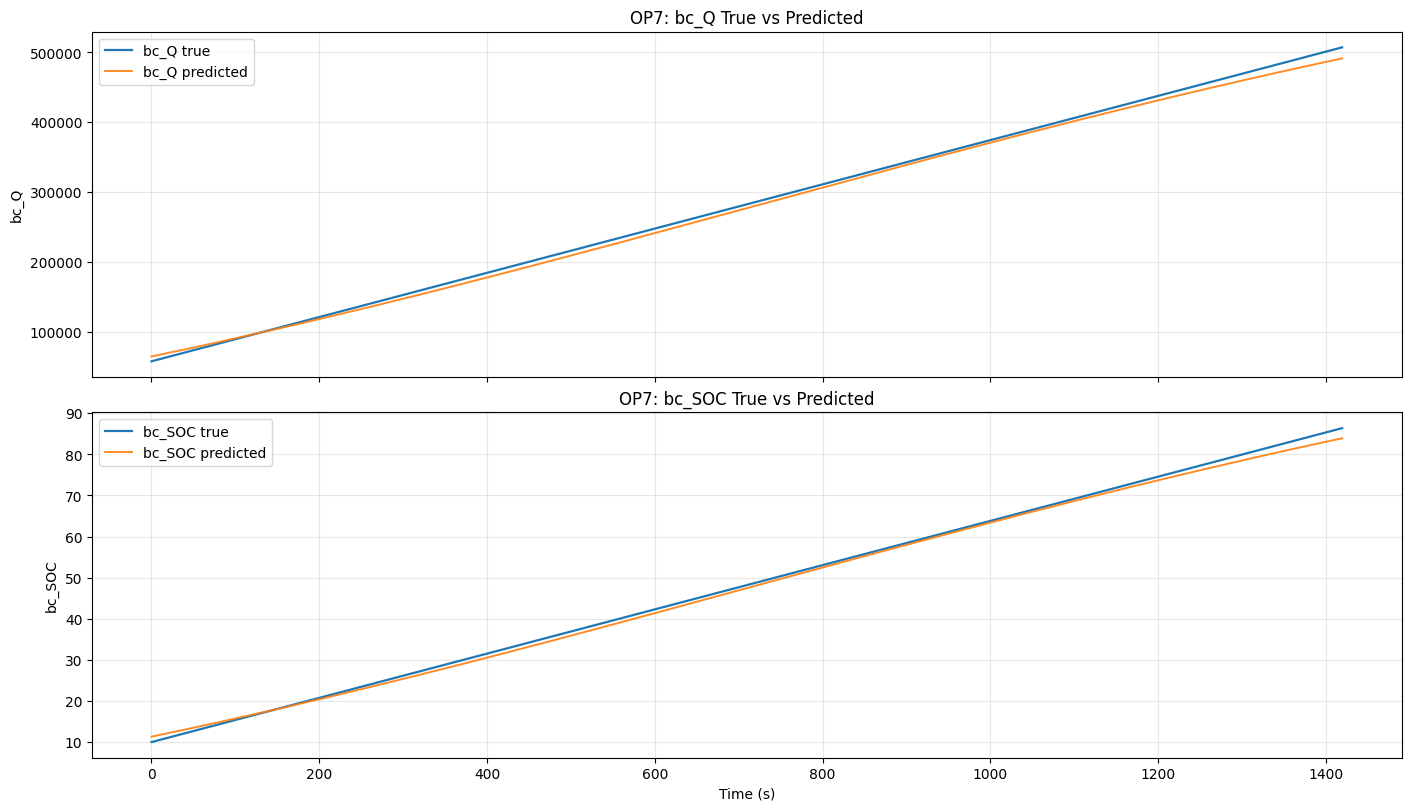

In [ ]:
# Verification plots and metrics on random OP1-OP6 samples.
import matplotlib.pyplot as plt

n_verify = 256

sampled_verify = sample(n_verify)
headers_verify = [str(h) for h in sampled_verify[0].tolist()]
values_verify = np.asarray(sampled_verify[1:], dtype=float)

op_idx = headers_verify.index("op_id")
q_idx = headers_verify.index("q")
soc_idx = headers_verify.index("soc")
feature_cols = scaler["feature_cols"]

op_ids = values_verify[:, op_idx].astype(int)
x_verify_np = values_verify[:, feature_cols]
y_verify_true = values_verify[:, [q_idx, soc_idx]]
x_verify_np_norm = (x_verify_np - scaler["x_mean"]) / scaler["x_std"]

model.eval()
with torch.no_grad():
    x_verify = torch.tensor(x_verify_np_norm, dtype=torch.float32, device=device)
    y_verify_pred = _denorm_y(model(x_verify), scaler).cpu().numpy()

q_true = y_verify_true[:, 0]
soc_true = y_verify_true[:, 1]
q_pred = y_verify_pred[:, 0]
soc_pred = y_verify_pred[:, 1]

q_abs_err = np.abs(q_pred - q_true)
soc_abs_err = np.abs(soc_pred - soc_true)
q_rmse = float(np.sqrt(np.mean((q_pred - q_true) ** 2)))
soc_rmse = float(np.sqrt(np.mean((soc_pred - soc_true) ** 2)))

print(f"Verification sample count: {n_verify}")
print(f"Overall q   MAE : {np.mean(q_abs_err):.6f}")
print(f"Overall q   RMSE: {q_rmse:.6f}")
print(f"Overall soc MAE : {np.mean(soc_abs_err):.6f}")
print(f"Overall soc RMSE: {soc_rmse:.6f}")

print("\nPer-OP MAE summary:")
print(" OP |      q_mae |    soc_mae | count")
print("----+------------+------------+------")
for op_id in sorted(np.unique(op_ids)):
    mask = op_ids == op_id
    print(
        f" {op_id:>2d} | {np.mean(q_abs_err[mask]):10.6f} | {np.mean(soc_abs_err[mask]):10.6f} | {np.sum(mask):5d}"
    )

fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

q_min = min(float(np.min(q_true)), float(np.min(q_pred)))
q_max = max(float(np.max(q_true)), float(np.max(q_pred)))
soc_min = min(float(np.min(soc_true)), float(np.min(soc_pred)))
soc_max = max(float(np.max(soc_true)), float(np.max(soc_pred)))

axes[0, 0].scatter(q_true, q_pred, s=18, alpha=0.7)
axes[0, 0].plot([q_min, q_max], [q_min, q_max], "k--", linewidth=1)
axes[0, 0].set_title("q: true vs predicted")
axes[0, 0].set_xlabel("q true")
axes[0, 0].set_ylabel("q predicted")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(soc_true, soc_pred, s=18, alpha=0.7, color="tab:orange")
axes[0, 1].plot([soc_min, soc_max], [soc_min, soc_max], "k--", linewidth=1)
axes[0, 1].set_title("soc: true vs predicted")
axes[0, 1].set_xlabel("soc true")
axes[0, 1].set_ylabel("soc predicted")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].hist(q_pred - q_true, bins=30, color="tab:blue", alpha=0.8)
axes[1, 0].set_title("q residuals")
axes[1, 0].set_xlabel("q_pred - q_true")
axes[1, 0].set_ylabel("count")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(soc_pred - soc_true, bins=30, color="tab:orange", alpha=0.8)
axes[1, 1].set_title("soc residuals")
axes[1, 1].set_xlabel("soc_pred - soc_true")
axes[1, 1].set_ylabel("count")
axes[1, 1].grid(True, alpha=0.3)

plt.show()